# Task 02 - Advanced Data Cleaning and Preprocessing

##Objective
The objective of this task is to clean and preprocess the Adult Census Income dataset by handling missing values, removing duplicates, treating outliers, encoding categorical features, scaling numerical features, and validating the data to prepare it for machine learning.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

##Load Dataset


In [2]:
import zipfile

with zipfile.ZipFile("adult.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
df = pd.read_csv("adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3. Initial Data Exploration

In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (32561, 15)

Column Names:
Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

Data Types:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


## 4. Missing Value Analysis

In [5]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [8]:
(df == "?").sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


### Replace '?' with NaN

In [9]:
import numpy as np

df.replace("?", np.nan, inplace=True)

In [10]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


### Missing Value Percentage

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

,0
occupation,5.660146
workclass,5.638647
native.country,1.790486


### Visualizing Missing Values

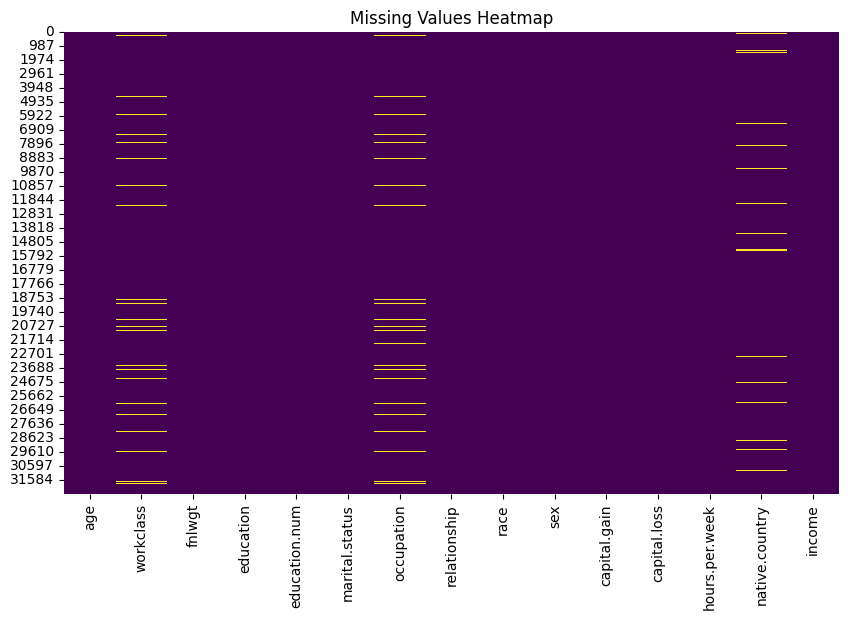

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

### Handling Missing Values

In [13]:
for column in ["workclass", "occupation", "native.country"]:
    df[column].fillna(df[column].mode()[0], inplace=True)

In [14]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


## 5. Duplicate Record Detection

In [15]:
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 24


### Removing Duplicate Records

In [16]:
df.drop_duplicates(inplace=True)

print("Remaining Duplicate Rows:", df.duplicated().sum())

Remaining Duplicate Rows: 0


In [17]:
duplicate_rows = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 0


### Removing Duplicate Records

The dataset contained 24 duplicate records. These duplicate rows were removed to improve data quality and prevent bias during machine learning. After removing the duplicates, the dataset was verified and no duplicate records remained.

## 6. Data Validation

In [19]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [20]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [21]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


### Validation Summary

After preprocessing, the dataset was validated to ensure there were no missing values or duplicate records. The data types were also checked to confirm that numerical and categorical features were correctly represented. The dataset is now clean and ready for further preprocessing and machine learning.

## 7. Encoding Categorical Features

In [22]:
categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [24]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


## 8. Feature Scaling

In [25]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')


In [26]:
scaler = MinMaxScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [27]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,1.000000,0.428571,0.043987,0.733333,0.533333,1.000000,0.692308,0.2,1.0,0.0,0.0,1.000000,0.397959,0.95,0.0
1,0.890411,0.428571,0.081896,0.733333,0.533333,1.000000,0.230769,0.2,1.0,0.0,0.0,1.000000,0.173469,0.95,0.0
2,0.671233,0.428571,0.118021,1.000000,0.600000,1.000000,0.692308,0.8,0.5,0.0,0.0,1.000000,0.397959,0.95,0.0
3,0.506849,0.428571,0.086982,0.333333,0.200000,0.000000,0.461538,0.8,1.0,0.0,0.0,0.895317,0.397959,0.95,0.0
4,0.328767,0.428571,0.171404,1.000000,0.600000,0.833333,0.692308,0.6,1.0,0.0,0.0,0.895317,0.397959,0.95,0.0


## 9. Evaluation

In [28]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Preview:")
df.head()

Final Dataset Shape: (32537, 15)

Missing Values:
0

Duplicate Rows:
0

Dataset Preview:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,1.000000,0.428571,0.043987,0.733333,0.533333,1.000000,0.692308,0.2,1.0,0.0,0.0,1.000000,0.397959,0.95,0.0
1,0.890411,0.428571,0.081896,0.733333,0.533333,1.000000,0.230769,0.2,1.0,0.0,0.0,1.000000,0.173469,0.95,0.0
2,0.671233,0.428571,0.118021,1.000000,0.600000,1.000000,0.692308,0.8,0.5,0.0,0.0,1.000000,0.397959,0.95,0.0
3,0.506849,0.428571,0.086982,0.333333,0.200000,0.000000,0.461538,0.8,1.0,0.0,0.0,0.895317,0.397959,0.95,0.0
4,0.328767,0.428571,0.171404,1.000000,0.600000,0.833333,0.692308,0.6,1.0,0.0,0.0,0.895317,0.397959,0.95,0.0


## 10. Business Impact
The dataset was successfully cleaned and preprocessed to improve its quality and reliability.

Handling missing values ensures that no important information is lost.

Removing duplicate records prevents biased analysis.

Encoding categorical variables makes the dataset compatible with machine learning algorithms.

Feature scaling ensures that numerical features contribute fairly during model training.

Overall, these preprocessing steps improve the quality of the data and help produce more reliable salary prediction models for HR analytics.

##Conclusion
In this task, advanced data cleaning and preprocessing techniques were applied to the Adult Census Income dataset.

Missing values were identified and handled, duplicate records were removed, categorical variables were encoded, numerical features were scaled, and the dataset was validated.

The final dataset is clean, consistent, and ready for machine learning model development.